<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    NLP Triagem Inteligente Financeira - Data Science Project
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                    Consolidação analítica e decisão técnica
                </strong>
            </font>
        </p>
        <p style="text-align: center;">
            <font size="5" color='#C58A1E'>
                <strong>
                    Consolidar os resultados dos modelos desenvolvidos no projeto, comparar baseline e transformer,<br />interpretar o comportamento observado e transformar os achados técnicos<br />em uma decisão prática para deployment inicial.
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento [-] Custo [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Mestre Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Objetivo:</strong></font>

<font size="2" color='#66666'>

>- **Ações realizadas neste notebook**
    - ***Leitura dos artefatos gerados nos Notebooks 04 e 05***
    - ***Comparação entre baseline e transformer***
    - ***Análise das métricas globais***
    - ***Leitura comparativa por classe***
    - ***Análise qualitativa dos erros***
    - ***Interpretação técnica e de negócio***
    - ***Recomendação de modelo para deployment inicial***

>- **Justificativa técnica**
    - Modelos não devem ser avaliados apenas por métricas isoladas.
    - Em um projeto aplicado, é essencial entender o trade-off entre desempenho, complexidade, interpretabilidade, robustez e custo operacional.

>- **Resultados esperados**
    - Comparação consolidada entre os modelos
    - Evidência clara do comportamento observado
    - Interpretação técnica honesta
    - Recomendação prática para uso inicial

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Leitura executiva da etapa</strong></font>

<font size="2" color='#66666'>

>- Este notebook representa o momento em que a modelagem deixa de ser apenas experimento e passa a orientar uma decisão de arquitetura.

>- A pergunta central aqui é:
    - **O transformer demonstrou ganho prático suficiente para justificar maior complexidade operacional no deployment inicial?**

>- Neste projeto, a análise será construída com base em:
    - métricas globais
    - desempenho por classe
    - análise qualitativa dos erros
    - custo/benefício técnico-operacional

>- **Nota metodológica importante**
    - A decisão deste notebook será orientada por evidência.
    - Se o modelo mais complexo não demonstrar ganho consistente, ele não será promovido a candidato principal apenas por ser mais moderno.

---

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 1 — Setup e leitura dos artefatos analíticos</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Carregar os resultados persistidos pelos Notebooks 04 e 05 para consolidar a comparação entre baseline e transformer.

>- **Ações realizadas**
    - ***Definição dos diretórios do projeto***
    - ***Leitura das métricas globais***
    - ***Leitura dos relatórios por classe***
    - ***Leitura das previsões de teste***
    - ***Organização das bases comparativas***

>- **Justificativa técnica**
    - Centralizar a leitura dos artefatos torna esta etapa reprodutível e evita reconstruções desnecessárias dentro do notebook.

>- **Resultados esperados**
    - Artefatos carregados corretamente
    - Base consolidada para análise comparativa


</font></div>

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 200)

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
REPORTS_DIR = PROJECT_ROOT / "artifacts" / "reports"
MODELS_DIR = PROJECT_ROOT / "models"
BASELINE_MODELS_DIR = MODELS_DIR / "baseline"
TRANSFORMER_MODELS_DIR = MODELS_DIR / "transformer"
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures"

print("PROJECT_ROOT          :", PROJECT_ROOT)
print("REPORTS_DIR           :", REPORTS_DIR)
print("BASELINE_MODELS_DIR   :", BASELINE_MODELS_DIR)
print("TRANSFORMER_MODELS_DIR:", TRANSFORMER_MODELS_DIR)
print("FIGURES_DIR           :", FIGURES_DIR)


PROJECT_ROOT          : D:\_DS-Projects\nlp-triagem-inteligente-financeira
REPORTS_DIR           : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports
BASELINE_MODELS_DIR   : D:\_DS-Projects\nlp-triagem-inteligente-financeira\models\baseline
TRANSFORMER_MODELS_DIR: D:\_DS-Projects\nlp-triagem-inteligente-financeira\models\transformer
FIGURES_DIR           : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\figures


In [4]:
baseline_metrics_path = REPORTS_DIR / "baseline_test_metrics.csv"
baseline_report_path = REPORTS_DIR / "baseline_test_classification_report.csv"
baseline_predictions_path = REPORTS_DIR / "baseline_test_predictions.csv"

transformer_metrics_path = REPORTS_DIR / "transformer_test_metrics.csv"
transformer_report_path = REPORTS_DIR / "transformer_test_classification_report.csv"
transformer_predictions_path = REPORTS_DIR / "transformer_test_predictions.csv"

comparison_path = REPORTS_DIR / "baseline_vs_transformer_comparison.csv"


In [5]:
baseline_metrics_df = pd.read_csv(baseline_metrics_path)
baseline_report_df = pd.read_csv(baseline_report_path, index_col=0)
baseline_predictions_df = pd.read_csv(baseline_predictions_path)

transformer_metrics_df = pd.read_csv(transformer_metrics_path)
transformer_report_df = pd.read_csv(transformer_report_path, index_col=0)
transformer_predictions_df = pd.read_csv(transformer_predictions_path)

if comparison_path.exists():
    comparison_df = pd.read_csv(comparison_path)
else:
    comparison_df = pd.DataFrame()

print("baseline_metrics_df        :", baseline_metrics_df.shape)
print("baseline_report_df         :", baseline_report_df.shape)
print("baseline_predictions_df    :", baseline_predictions_df.shape)
print("transformer_metrics_df     :", transformer_metrics_df.shape)
print("transformer_report_df      :", transformer_report_df.shape)
print("transformer_predictions_df :", transformer_predictions_df.shape)
print("comparison_df              :", comparison_df.shape)


baseline_metrics_df        : (1, 5)
baseline_report_df         : (242, 4)
baseline_predictions_df    : (373, 13)
transformer_metrics_df     : (1, 5)
transformer_report_df      : (242, 4)
transformer_predictions_df : (373, 13)
comparison_df              : (2, 6)


<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- Este notebook parte do pressuposto de que:
    - o baseline foi salvo no Notebook 04
    - o transformer foi salvo no Notebook 05
    - ambos foram avaliados sobre o mesmo conjunto de teste
    - a recomendação final será baseada nesses artefatos persistidos

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 2 — Consolidação das métricas globais</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Comparar baseline e transformer com base nas métricas globais do conjunto de teste.

>- **Ações realizadas**
    - ***Organização das métricas em uma tabela comparativa***
    - ***Cálculo de delta entre os modelos***
    - ***Visualização gráfica dos principais indicadores***

>- **Justificativa técnica**
    - As métricas globais oferecem a primeira leitura do ganho — ou da perda — do modelo avançado em relação à linha de base.

>- **Resultados esperados**
    - Comparação objetiva entre os modelos
    - Ganho absoluto ou perda do transformer identificados

</font></div>

In [6]:
baseline_metrics = baseline_metrics_df.iloc[0].to_dict()
transformer_metrics = transformer_metrics_df.iloc[0].to_dict()

comparison_df = pd.DataFrame(
    [
        {"model": "baseline_tfidf_logreg", **baseline_metrics},
        {"model": "transformer_bertimbau", **transformer_metrics},
    ]
)

comparison_df

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,baseline_tfidf_logreg,0.302949,0.236813,0.302842,0.255719,0.263999
1,transformer_bertimbau,0.176944,0.002059,0.053204,0.001212,0.006849


In [7]:
comparison_df.style.format(
    {
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
    }
)

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,baseline_tfidf_logreg,0.3029,0.2368,0.3028,0.2557,0.2640
1,transformer_bertimbau,0.1769,0.0021,0.0532,0.0012,0.0068


In [8]:
delta_df = pd.DataFrame(
    [
        {
            "metric": metric,
            "baseline": float(baseline_metrics[metric]),
            "transformer": float(transformer_metrics[metric]),
            "delta_transformer_minus_baseline": float(transformer_metrics[metric]) - float(baseline_metrics[metric]),
        }
        for metric in ["accuracy", "macro_f1", "weighted_f1", "macro_precision", "macro_recall"]
    ]
)

delta_df

,metric,baseline,transformer,delta_transformer_minus_baseline
0,accuracy,0.302949,0.176944,-0.126005
1,macro_f1,0.236813,0.002059,-0.234753
2,weighted_f1,0.302842,0.053204,-0.249638
3,macro_precision,0.255719,0.001212,-0.254507
4,macro_recall,0.263999,0.006849,-0.257149


In [9]:
delta_df.style.format(
    {
        "baseline": "{:.4f}",
        "transformer": "{:.4f}",
        "delta_transformer_minus_baseline": "{:+.4f}",
    }
)

,metric,baseline,transformer,delta_transformer_minus_baseline
0,accuracy,0.3029,0.1769,-0.1260
1,macro_f1,0.2368,0.0021,-0.2348
2,weighted_f1,0.3028,0.0532,-0.2496
3,macro_precision,0.2557,0.0012,-0.2545
4,macro_recall,0.2640,0.0068,-0.2571


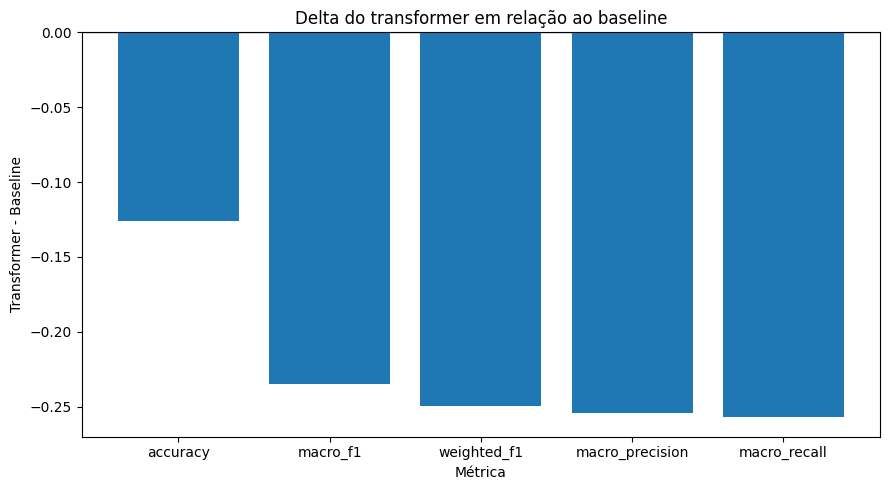

In [10]:
plt.figure(figsize=(9, 5))
plt.bar(delta_df["metric"], delta_df["delta_transformer_minus_baseline"])
plt.axhline(0, linewidth=1)
plt.title("Delta do transformer em relação ao baseline")
plt.xlabel("Métrica")
plt.ylabel("Transformer - Baseline")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- A métrica mais importante para esta tarefa é **Macro F1**, pois ela oferece uma visão mais equilibrada entre classes.

>- ***Se o transformer tiver desempenho muito inferior em Macro F1, isso indica que ele não apenas deixou de melhorar o projeto — ele pode ter comprometido a capacidade de generalização multiclasses.***

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 3 — Diagnóstico do comportamento observado</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Interpretar tecnicamente o padrão de desempenho observado no transformer.

>- **Ações realizadas**
    - ***Leitura do comportamento do modelo no teste***
    - ***Medição do número de classes efetivamente previstas***
    - ***Identificação da classe dominante nas previsões***

>- **Justificativa técnica**
    - *Quando um modelo multiclasses apresenta Macro F1 muito próximo de zero, frequentemente há colapso para poucas classes ou para uma classe majoritária*.

>- **Resultados esperados**
    - Diagnóstico técnico do experimento transformer
    - Evidência do padrão de colapso observado

</font></div>

In [13]:
transformer_pred_counts = (
    transformer_predictions_df["pred_label"]
    .value_counts()
    .rename_axis("pred_label")
    .reset_index(name="count")
)

transformer_pred_counts.head(20)

,pred_label,count
0,SEM-CATEGORIA,373


In [14]:
n_unique_transformer_preds = transformer_predictions_df["pred_label"].nunique()
n_unique_baseline_preds = baseline_predictions_df["pred_label"].nunique()

pd.DataFrame(
    [
        {"model": "baseline_tfidf_logreg", "n_unique_predicted_labels": n_unique_baseline_preds},
        {"model": "transformer_bertimbau", "n_unique_predicted_labels": n_unique_transformer_preds},
    ]
)

,model,n_unique_predicted_labels
0,baseline_tfidf_logreg,164
1,transformer_bertimbau,1


In [15]:
top_transformer_pred = transformer_pred_counts.iloc[0].to_dict()
top_transformer_pred

{'pred_label': 'SEM-CATEGORIA', 'count': 373}

<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Interpretação do diagnóstico</strong></font>

<font size="2" color='#66666'>

>- Se o transformer concentrou previsões em uma única classe dominante, isso caracteriza um comportamento incompatível com o objetivo do projeto.

>- Neste contexto, **o experimento não deve ser lido como “fracasso da abordagem transformer em geral”**, mas como:
    - ***formulação ainda inadequada para o espaço atual de classes***
    - ***alta dificuldade do problema na granularidade adotada***
    - ***necessidade de redesign do experimento antes de nova rodada***

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 4 — Comparação por classe</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Comparar baseline e transformer no nível das classes individuais.

>- **Ações realizadas**
    - ***Extração das métricas por classe***
    - ***Consolidação em uma tabela comparativa***
    - ***Cálculo do delta de F1 por classe***
    - ***Identificação das maiores melhorias e maiores perdas***

>- **Justificativa técnica**
    - Ganhos ou perdas globais podem esconder comportamentos muito diferentes entre classes.

>- **Resultados esperados**
    - Comparação detalhada entre classes
    - Classes mais impactadas identificadas

</font></div>

In [16]:
baseline_class_df = baseline_report_df.copy()
transformer_class_df = transformer_report_df.copy()

for df_ in [baseline_class_df, transformer_class_df]:
    for col in ["precision", "recall", "f1-score", "support"]:
        if col in df_.columns:
            df_[col] = pd.to_numeric(df_[col], errors="coerce")

In [17]:
summary_rows = {"accuracy", "macro avg", "weighted avg"}

baseline_classes_only = baseline_class_df.loc[~baseline_class_df.index.isin(summary_rows)].copy()
transformer_classes_only = transformer_class_df.loc[~transformer_class_df.index.isin(summary_rows)].copy()

class_comparison_df = baseline_classes_only[["precision", "recall", "f1-score", "support"]].rename(
    columns={
        "precision": "baseline_precision",
        "recall": "baseline_recall",
        "f1-score": "baseline_f1",
        "support": "support",
    }
).join(
    transformer_classes_only[["precision", "recall", "f1-score"]].rename(
        columns={
            "precision": "transformer_precision",
            "recall": "transformer_recall",
            "f1-score": "transformer_f1",
        }
    ),
    how="inner"
)

class_comparison_df["delta_f1"] = class_comparison_df["transformer_f1"] - class_comparison_df["baseline_f1"]
class_comparison_df["delta_recall"] = class_comparison_df["transformer_recall"] - class_comparison_df["baseline_recall"]

class_comparison_df.head(20)

,baseline_precision,baseline_recall,baseline_f1,support,transformer_precision,transformer_recall,transformer_f1,delta_f1,delta_recall
Cadastro Informativo de créditos não quitados do setor público federal (Cadin) Exclusão dos dados do Cadin,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,-1.000000,-1.000000
CBE - Capitais Brasileiros no Exterior Obrigatoriedade da declaração,1.000000,1.000000,1.000000,2.0,0.0,0.0,0.0,-1.000000,-1.000000
Cadastro de Clientes do Sistema Financeiro Nacional (CCS) Dados do CCS,1.000000,1.000000,1.000000,3.0,0.0,0.0,0.0,-1.000000,-1.000000
Cartão de Crédito Internacional,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,-1.000000,-1.000000
Empréstimos consignados Cartão de crédito consignado,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,-1.000000,-1.000000
Consórcios Aquisição de bens e serviços,1.000000,1.000000,1.000000,2.0,0.0,0.0,0.0,-1.000000,-1.000000
Crédito Rural Renegociação das dívidas,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,-1.000000,-1.000000
Crédito Rural Monitoramento e Fiscalização,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,-1.000000,-1.000000
Empréstimos consignados Principais dúvidas,1.000000,1.000000,1.000000,2.0,0.0,0.0,0.0,-1.000000,-1.000000
Empréstimos consignados Margem Consignável,1.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,-1.000000,-1.000000


In [18]:
class_comparison_df.style.format(
    {
        "baseline_precision": "{:.4f}",
        "baseline_recall": "{:.4f}",
        "baseline_f1": "{:.4f}",
        "transformer_precision": "{:.4f}",
        "transformer_recall": "{:.4f}",
        "transformer_f1": "{:.4f}",
        "delta_f1": "{:+.4f}",
        "delta_recall": "{:+.4f}",
    }
)

,baseline_precision,baseline_recall,baseline_f1,support,transformer_precision,transformer_recall,transformer_f1,delta_f1,delta_recall
Cadastro Informativo de créditos não quitados do setor público federal (Cadin) Exclusão dos dados do Cadin,1.0000,1.0000,1.0000,1.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
CBE - Capitais Brasileiros no Exterior Obrigatoriedade da declaração,1.0000,1.0000,1.0000,2.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Cadastro de Clientes do Sistema Financeiro Nacional (CCS) Dados do CCS,1.0000,1.0000,1.0000,3.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Cartão de Crédito Internacional,1.0000,1.0000,1.0000,1.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Empréstimos consignados Cartão de crédito consignado,1.0000,1.0000,1.0000,1.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Consórcios Aquisição de bens e serviços,1.0000,1.0000,1.0000,2.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Crédito Rural Renegociação das dívidas,1.0000,1.0000,1.0000,1.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Crédito Rural Monitoramento e Fiscalização,1.0000,1.0000,1.0000,1.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Empréstimos consignados Principais dúvidas,1.0000,1.0000,1.0000,2.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000
Empréstimos consignados Margem Consignável,1.0000,1.0000,1.0000,1.000000,0.0000,0.0000,0.0000,-1.0000,-1.0000


In [19]:
top_gain_classes = class_comparison_df.sort_values(by="delta_f1", ascending=False).head(15).copy()
top_loss_classes = class_comparison_df.sort_values(by="delta_f1", ascending=True).head(15).copy()

top_gain_classes[["baseline_f1", "transformer_f1", "delta_f1", "support"]]

,baseline_f1,transformer_f1,delta_f1,support
SEM-CATEGORIA,0.0,0.300683,0.300683,66.0
Cadastro Positivo Solicitação de cancelamento ou suspensão do cadastro positivo,0.0,0.000000,0.000000,0.0
Cadastro Positivo Conceitos importantes,0.0,0.000000,0.000000,0.0
CBE - Capitais Brasileiros no Exterior Exportações,0.0,0.000000,0.000000,0.0
CBE - Capitais Brasileiros no Exterior Entrega e Retificação,0.0,0.000000,0.000000,1.0
Banco Central do Brasil,0.0,0.000000,0.000000,2.0
Bacen Jud e SISBAJUD Ordem judicial de bloqueio/desbloqueio de bens e requisição de informações,0.0,0.000000,0.000000,0.0
Bacen Jud e SISBAJUD SISBAJUD,0.0,0.000000,0.000000,0.0
"Atendimento bancário (fila, feriados e outros)",0.0,0.000000,0.000000,4.0
Bacen Jud e SISBAJUD Informações gerais,0.0,0.000000,0.000000,0.0


In [20]:
top_loss_classes[["baseline_f1", "transformer_f1", "delta_f1", "support"]]

,baseline_f1,transformer_f1,delta_f1,support
Cadastro Informativo de créditos não quitados do setor público federal (Cadin) Exclusão dos dados do Cadin,1.0,0.0,-1.0,1.0
CBE - Capitais Brasileiros no Exterior Obrigatoriedade da declaração,1.0,0.0,-1.0,2.0
Cadastro de Clientes do Sistema Financeiro Nacional (CCS) Dados do CCS,1.0,0.0,-1.0,3.0
Cartão de Crédito Internacional,1.0,0.0,-1.0,1.0
Empréstimos consignados Cartão de crédito consignado,1.0,0.0,-1.0,1.0
Consórcios Aquisição de bens e serviços,1.0,0.0,-1.0,2.0
Crédito Rural Renegociação das dívidas,1.0,0.0,-1.0,1.0
Crédito Rural Monitoramento e Fiscalização,1.0,0.0,-1.0,1.0
Empréstimos consignados Principais dúvidas,1.0,0.0,-1.0,2.0
Empréstimos consignados Margem Consignável,1.0,0.0,-1.0,1.0


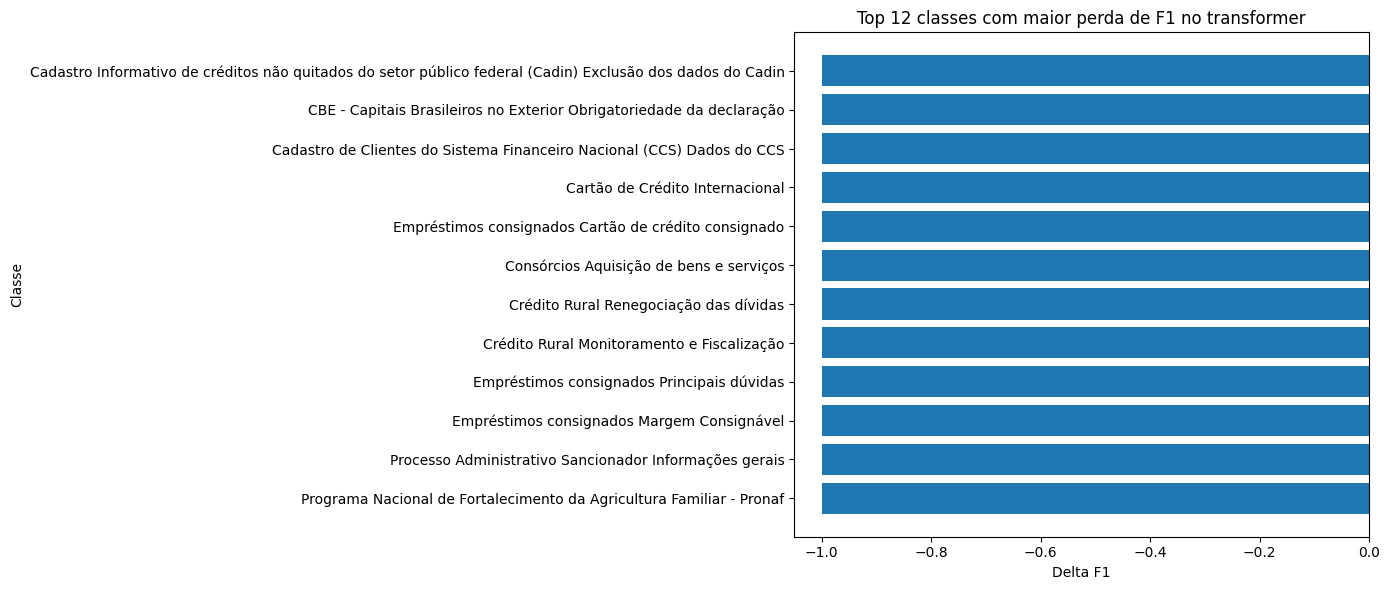

In [24]:
plot_loss_df = class_comparison_df.sort_values(by="delta_f1", ascending=True).head(12)

plt.figure(figsize=(14, 6))
plt.barh(plot_loss_df.index[::-1], plot_loss_df["delta_f1"][::-1])
plt.title("Top 12 classes com maior perda de F1 no transformer")
plt.xlabel("Delta F1")
plt.ylabel("Classe")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Observe:</strong></font>

<font size="2" color='#66666'>

>- Neste projeto, a leitura por classe tem um papel ainda mais importante porque o comportamento do transformer sugere concentração excessiva de previsões em uma classe dominante.

>- Assim, a comparação por classe deve ser lida principalmente como:
    - evidência de perda de cobertura
    - evidência de colapso multiclasses
    - base para reprojetar o experimento futuro

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 5 — Comparação qualitativa dos erros</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Comparar qualitativamente os erros do baseline e do transformer sobre o conjunto de teste.

>- **Ações realizadas**
    - ***Identificação das previsões incorretas***
    - ***Comparação das quantidades de erro***
    - ***Inspeção de exemplos representativos***

>- **Justificativa técnica**
    - Além das métricas, a análise qualitativa ajuda a entender se o modelo avançado corrige erros relevantes ou apenas redistribui — ou concentra — os erros.

>- **Resultados esperados**
    - Visão concreta da diferença entre os modelos
    - Exemplos úteis para interpretação técnica e narrativa de portfólio

</font></div>

In [25]:
baseline_errors = baseline_predictions_df[baseline_predictions_df["is_error"] == True].copy()
transformer_errors = transformer_predictions_df[transformer_predictions_df["is_error"] == True].copy()

error_summary_df = pd.DataFrame(
    [
        {"model": "baseline_tfidf_logreg", "n_errors": baseline_errors.shape[0]},
        {"model": "transformer_bertimbau", "n_errors": transformer_errors.shape[0]},
    ]
)

error_summary_df

,model,n_errors
0,baseline_tfidf_logreg,260
1,transformer_bertimbau,307


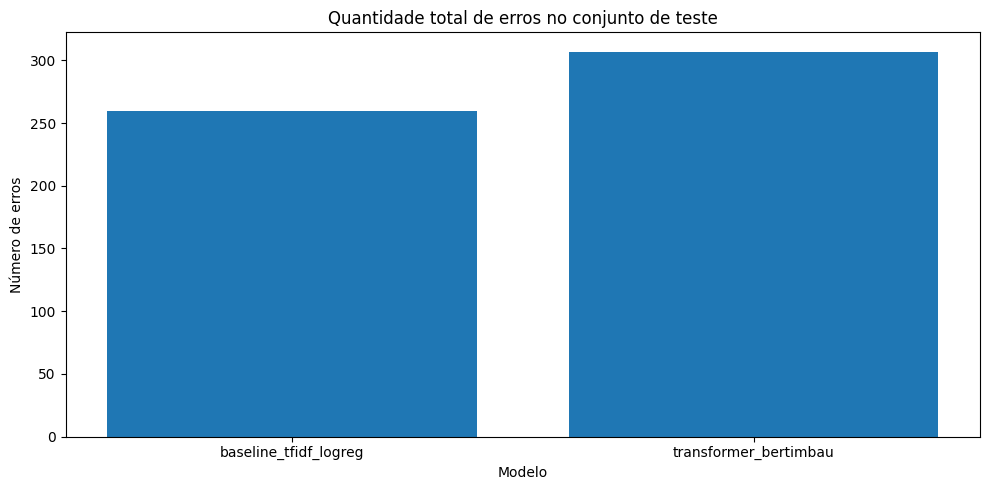

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(error_summary_df["model"], error_summary_df["n_errors"])
plt.title("Quantidade total de erros no conjunto de teste")
plt.ylabel("Número de erros")
plt.xlabel("Modelo")
plt.tight_layout()
plt.show()

In [28]:
baseline_top_confusions = (
    baseline_errors.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .query("true_label != pred_label")
    .sort_values("count", ascending=False)
    .head(15)
)

transformer_top_confusions = (
    transformer_errors.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .query("true_label != pred_label")
    .sort_values("count", ascending=False)
    .head(15)
)

baseline_top_confusions.head(10)

,true_label,pred_label,count
24,Calculadora do cidadão Informações gerais,Calculadora do cidadão Metodologia e cálculos,3
188,SEM-CATEGORIA,Pagamento Instantâneo (Pix) Entendendo como receber um Pix,3
149,Registro Declaratório Eletrônico - Registro de Operações Financeiras (RDE-ROF) Registro de operações de Empréstimos Diretos ou Títulos,Registro Declaratório Eletrônico - Registro de Operações Financeiras (RDE-ROF) Acesso ao RDE-ROF,3
169,SEM-CATEGORIA,Cédulas Falsas e Suspeitas Cédula falsa ou suspeita sacada em banco,3
174,SEM-CATEGORIA,Cédulas manchadas de tinta,3
64,"Empréstimo, financiamento e arrendamento mercantil (leasing) Formas de contratação e cuidados ao contratar operações de crédito",Microcrédito Microcrédito Produtivo Orientado – Limites e requisitos,2
75,Importações Pagamento das importações,Importações Informações gerais,2
89,Mercado de câmbio,Câmbio,2
63,"Empréstimo, financiamento e arrendamento mercantil (leasing) Custo Efetivo Total (CET)","Empréstimo, financiamento e arrendamento mercantil (leasing) Formas de contratação e cuidados ao contratar operações de crédito",2
18,Cadastro Informativo de créditos não quitados do setor público federal (Cadin) Consulta aos meus dados no Cadin,Cadastro Informativo de créditos não quitados do setor público federal (Cadin) Informações gerais,2


In [29]:
transformer_top_confusions.head(10)

,true_label,pred_label,count
78,Liquidação Extrajudicial - Consórcios,SEM-CATEGORIA,7
143,Transferências,SEM-CATEGORIA,7
138,Sistema de Pagamentos em Moeda Local (SML),SEM-CATEGORIA,7
125,Registrato,SEM-CATEGORIA,6
94,Pagamento Instantâneo (Pix) Entendendo como se faz um Pix,SEM-CATEGORIA,6
24,Cartão de Crédito e Crédito Rotativo,SEM-CATEGORIA,6
118,Programa Nacional de Fortalecimento da Agricultura Familiar - Pronaf,SEM-CATEGORIA,6
88,Open Banking Informações gerais,SEM-CATEGORIA,6
140,Tarifas bancárias,SEM-CATEGORIA,5
129,Registro Declaratório Eletrônico - Registro de Operações Financeiras (RDE-ROF) Registro de operações de Empréstimos Diretos ou Títulos,SEM-CATEGORIA,5


In [30]:
baseline_errors[["question_raw", "true_label", "pred_label"]].head(10)

,question_raw,true_label,pred_label
0,Qual a diferença entre credenciadores e subcredenciadores?,Instituições de Pagamento,"Pagamento Instantâneo (Pix) Entendendo a diferença entre o Pix e os outros meios de pagamento (TED, DOC, boleto bancário e cartões)"
2,O que devo fazer se suspeitar que uma cédula pode ser falsa?,"Cédula de R$200,00 Itens de segurança e falsificações",Cédulas Falsas e Suspeitas Identificação de cédulas falsas ou suspeitas
3,"Com o Pix, a TED e o DOC vão acabar?","Pagamento Instantâneo (Pix) Entendendo a diferença entre o Pix e os outros meios de pagamento (TED, DOC, boleto bancário e cartões)",Transferências
4,Todas as operações de câmbio de uma instituição compõem a média calculada para classificação?,SEM-CATEGORIA,Câmbio
5,Como se classificam os recursos do crédito rural?,SEM-CATEGORIA,Crédito Rural Informações Gerais
6,Quando os recursos livres de clientes em posse da corretora serão liberados?,Liquidação Extrajudicial - Corretoras de Títulos e Valores Mobiliários,Liquidação Extrajudicial - Corretoras de câmbio
7,"Quero efetuar o pagamento de uma conta com um cheque, mas o banco se recusa a receber. O procedimento do banco está correto?",Cheques Talão de cheque,Cheques Sustação e revogação de cheque
10,Qual o horário de funcionamento das agências bancárias?,"Atendimento bancário (fila, feriados e outros)",Processos de Autorização do Banco Central Processo de autorização para constituição e funcionamento – Geral
11,Os bancos centrais atuam como garantidores das operações?,Sistema de Pagamentos em Moeda Local (SML),Microcrédito Microcrédito
13,Quais as consequências para o correntista que sustar indevidamente o seu pagamento?,Cheques Sustação e revogação de cheque,Cheques Devolução de cheques


In [31]:
transformer_errors[["question_raw", "true_label", "pred_label"]].head(10)

,question_raw,true_label,pred_label
0,Qual a diferença entre credenciadores e subcredenciadores?,Instituições de Pagamento,SEM-CATEGORIA
1,O cliente pode revogar o consentimento anterior?,Open Banking Autorização do cliente para compartilhamento de seus dados,SEM-CATEGORIA
2,O que devo fazer se suspeitar que uma cédula pode ser falsa?,"Cédula de R$200,00 Itens de segurança e falsificações",SEM-CATEGORIA
3,"Com o Pix, a TED e o DOC vão acabar?","Pagamento Instantâneo (Pix) Entendendo a diferença entre o Pix e os outros meios de pagamento (TED, DOC, boleto bancário e cartões)",SEM-CATEGORIA
6,Quando os recursos livres de clientes em posse da corretora serão liberados?,Liquidação Extrajudicial - Corretoras de Títulos e Valores Mobiliários,SEM-CATEGORIA
7,"Quero efetuar o pagamento de uma conta com um cheque, mas o banco se recusa a receber. O procedimento do banco está correto?",Cheques Talão de cheque,SEM-CATEGORIA
8,Quais dados estão contidos no CCS?,Cadastro de Clientes do Sistema Financeiro Nacional (CCS) Dados do CCS,SEM-CATEGORIA
9,Quais são as condições básicas dos créditos de investimento do Pronaf - Floresta?,Programa Nacional de Fortalecimento da Agricultura Familiar - Pronaf,SEM-CATEGORIA
10,Qual o horário de funcionamento das agências bancárias?,"Atendimento bancário (fila, feriados e outros)",SEM-CATEGORIA
11,Os bancos centrais atuam como garantidores das operações?,Sistema de Pagamentos em Moeda Local (SML),SEM-CATEGORIA


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 6 — Interpretação técnica e de negócio</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Traduzir os achados analíticos em implicações práticas para um cenário real de triagem inteligente no setor financeiro.

>- **Ações realizadas**
    - ***Interpretação do ganho ou perda do transformer***
    - ***Discussão sobre risco operacional***
    - ***Discussão sobre custo/benefício***
    - ***Formulação da recomendação de uso inicial***

>- **Justificativa técnica**
    - Em um projeto aplicado, a melhor decisão nem sempre é “o modelo mais sofisticado”.
    - É preciso considerar também interpretabilidade, custo, latência, robustez e governança.

>- **Resultados esperados**
    - Leitura conectada ao negócio
    - Base sólida para recomendação de deployment

</font></div>

In [32]:
macro_f1_delta = float(transformer_metrics["macro_f1"]) - float(baseline_metrics["macro_f1"])
accuracy_delta = float(transformer_metrics["accuracy"]) - float(baseline_metrics["accuracy"])
weighted_f1_delta = float(transformer_metrics["weighted_f1"]) - float(baseline_metrics["weighted_f1"])

business_interpretation_df = pd.DataFrame(
    [
        ["Ganho global", "Macro F1", macro_f1_delta],
        ["Ganho global", "Accuracy", accuracy_delta],
        ["Ganho global", "Weighted F1", weighted_f1_delta],
    ],
    columns=["dimensao", "metrica", "delta"]
)

business_interpretation_df

,dimensao,metrica,delta
0,Ganho global,Macro F1,-0.234753
1,Ganho global,Accuracy,-0.126005
2,Ganho global,Weighted F1,-0.249638


<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Leituras possíveis para o negócio</strong></font>

<font size="2" color='#66666'>

>- **O que os resultados mostram neste projeto**
    - o baseline entregou desempenho significativamente superior
    - o transformer não demonstrou ganho prático na formulação atual
    - a maior complexidade do transformer não foi compensada por melhoria de qualidade

>- **Implicação operacional**
    - Promover o transformer para produção neste estado aumentaria:
        - complexidade de serving
        - custo de manutenção
        - risco de roteamento incorreto
        - dificuldade de explicação do comportamento observado

>- **Interpretação madura**
    - Neste contexto, a decisão correta não é insistir no modelo mais complexo, mas preservar o modelo que demonstrou melhor comportamento empírico no problema formulado.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 7 — Recomendação técnica para deployment inicial</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Formalizar uma recomendação clara de arquitetura inicial para o classificador do projeto.

>- **Ações realizadas**
    - ***Consolidação das vantagens e limitações***
    - ***Definição de cenário recomendado***
    - ***Formulação de trilha evolutiva do transformer***

>- **Justificativa técnica**
    - A decisão de deployment precisa equilibrar desempenho, custo, robustez, simplicidade operacional e governança.

>- **Resultados esperados**
    - Recomendação clara e justificável
    - Encerramento técnico do ciclo de avaliação

</font></div>

In [33]:
recommendation_df = pd.DataFrame(
    [
        [
            "Baseline TF-IDF + Logistic Regression",
            "Melhor desempenho observado no teste; maior simplicidade operacional; menor custo",
            "Pode perder capacidade em classes semanticamente muito próximas",
            "Deployment inicial / MVP operacional / fallback robusto",
        ],
        [
            "Transformer",
            "Maior potencial contextual em formulações futuras",
            "Não validado com sucesso na formulação atual; colapso para classe dominante",
            "Trilha de evolução experimental, não candidato principal no estado atual",
        ],
    ],
    columns=["opcao", "forca_principal", "limitacao_principal", "cenario_indicado"]
)

recommendation_df

,opcao,forca_principal,limitacao_principal,cenario_indicado
0,Baseline TF-IDF + Logistic Regression,Melhor desempenho observado no teste; maior simplicidade operacional; menor custo,Pode perder capacidade em classes semanticamente muito próximas,Deployment inicial / MVP operacional / fallback robusto
1,Transformer,Maior potencial contextual em formulações futuras,Não validado com sucesso na formulação atual; colapso para classe dominante,"Trilha de evolução experimental, não candidato principal no estado atual"


<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Recomendação proposta</strong></font>

<font size="2" color='#66666'>

>- **Recomendação principal**
    - **Modelo recomendado para deployment inicial: Baseline TF-IDF + Logistic Regression**

>- **Justificativa**
    - O baseline demonstrou:
        - melhor qualidade preditiva
        - melhor comportamento multiclasses
        - menor complexidade de implantação
        - maior previsibilidade operacional

>- **Status do transformer**
    - O transformer deve ser tratado como:
        - **experimento exploratório relevante**
        - **evidência de que a formulação atual precisa ser reprojetada**
        - **trilha futura, não solução aprovada para o primeiro deployment**

>- **Próxima hipótese de evolução**
    - A próxima rodada transformer deve considerar:
        - ***uso de `question_raw`***
        - ***redução da granularidade do target***
        - ***agrupamento de classes raras***
        - ***nova rodada de fine-tuning com taxonomia mais viável***

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 8 — Persistência dos resultados consolidados</strong></font>

<font size="2" color='#66666'>
    
>- **Objetivo da seção**
    - Salvar as análises consolidadas deste notebook para uso em documentação, README, HTML e próxima etapa do projeto.

>- **Ações realizadas**
    - ***Persistência da tabela de comparação global***
    - ***Persistência da comparação por classe***
    - ***Persistência da recomendação de deployment***
    - ***Persistência do diagnóstico do experimento***

>- **Justificativa técnica**
    - Salvar essas saídas fortalece a rastreabilidade e facilita a montagem da documentação executiva do projeto.

>- **Resultados esperados**
    - Arquivos consolidados disponíveis na pasta de reports

</font></div>

In [34]:
delta_path = REPORTS_DIR / "baseline_vs_transformer_metric_deltas.csv"
class_comparison_path = REPORTS_DIR / "baseline_vs_transformer_class_comparison.csv"
recommendation_path = REPORTS_DIR / "deployment_recommendation_table.csv"
error_summary_path = REPORTS_DIR / "model_error_summary.csv"
transformer_pred_distribution_path = REPORTS_DIR / "transformer_prediction_distribution.csv"

delta_df.to_csv(delta_path, index=False)
class_comparison_df.to_csv(class_comparison_path)
recommendation_df.to_csv(recommendation_path, index=False)
error_summary_df.to_csv(error_summary_path, index=False)
transformer_pred_counts.to_csv(transformer_pred_distribution_path, index=False)

print("Arquivos consolidados salvos com sucesso:")
print(delta_path)
print(class_comparison_path)
print(recommendation_path)
print(error_summary_path)
print(transformer_pred_distribution_path)


Arquivos consolidados salvos com sucesso:
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\baseline_vs_transformer_metric_deltas.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\baseline_vs_transformer_class_comparison.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\deployment_recommendation_table.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\model_error_summary.csv
D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports\transformer_prediction_distribution.csv


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Seção 9 — Encerramento executivo</strong></font>

<font size="2" color='#66666'>
   
>- **Síntese da etapa**
    - Este notebook consolidou a comparação entre baseline e transformer e transformou os resultados de modelagem em uma recomendação prática de arquitetura.

>- **Principais entregas**
    - comparação global entre os modelos
    - comparação por classe
    - leitura qualitativa dos erros
    - diagnóstico do comportamento do transformer
    - recomendação técnica para deployment inicial

>- **Valor para o projeto**
    - Com esta etapa, o projeto deixa de ser apenas uma sequência de notebooks e passa a demonstrar:
        1. método  
        2. avaliação rigorosa  
        3. honestidade analítica  
        4. maturidade para decisão técnica

</font></div>

<div style="background-color:#f3f2ee">
    
<font size="3" color='#CC403E'><strong>📌 Próximo passo do projeto</strong></font>

<font size="2" color='#66666'>

>- No **Notebook 07 — Deployment & Monitoring**, vamos preparar:
    - carregamento do modelo escolhido
    - API REST para inferência
    - logging de predições
    - estrutura inicial de monitoramento

>- **Decisão levada para a próxima etapa:**
    - o deployment inicial será construído sobre o **baseline TF-IDF + Logistic Regression**.

---
</font></div>

<div style="background-color:#f3f2ee">
    
<font size="6" color='#CC403E'><strong>Fim</strong></font>

<font size="3" color='#66666'></font></div>


In [35]:
#!uv pip install nbconvert -U -q
!jupyter nbconvert --to html --template-file my-template-html-v10.tpl 06_evaluation_business_interpretation.ipynb

[NbConvertApp] Converting notebook 06_evaluation_business_interpretation.ipynb to html
[NbConvertApp] Writing 398926 bytes to 06_evaluation_business_interpretation.html
